#### **Can we use Monte Carlo simulations to get a sensible estimate for option delta? How does this compare to our Black-Scholes benchmark?**

In [6]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from black_scholes import BlackScholes
from discrete_delta_hedging import MC_delta

Delta measures the sensitivity of an option price to movements in the price of the asset underlying the option contract. Similar to the option price itself, the option delta has a closed form solution under the Black-Scholes framework. Our methodology for approximating delta will be to use Monte Carlo simulation to value our option at two very close but different theoretical spot prices: $S_0 + h$ and $S_0 - h$ for some small perturbation $h > 0$. These give rise to $V_{MC}^+$ and $V_{MC}^-$ respectively. We can then apply finite differencing to get an estimate for the delta:
$$
\Delta_{MC} = \frac{V_{MC}^+ - V_{MC}^-}{2h}\,.
$$
Below we apply this methodology over $100,000$ simulations for a given set of parameters.

In [4]:
delta = MC_delta(
    call=True,
    n_paths=100_000,
    S0=100,
    K=100,
    r=0.05,
    vol=0.2,
    T=1
)

print(f"Delta estimate: {round(delta, 4)}")

Delta estimate: 0.639


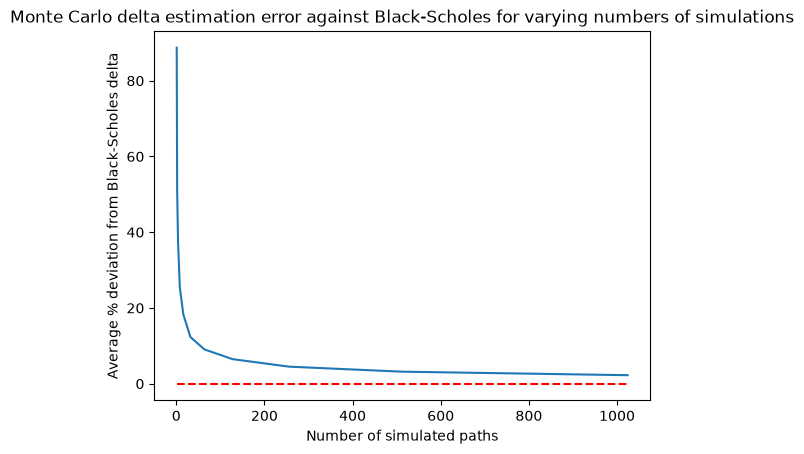

In [7]:
n_vals = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
mean_errors = []

for n in n_vals:
    error = 0
    
    for i in range(1000):
        delta_estimate = MC_delta(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1
        )

        _, delta_BS = BlackScholes(
            call=True,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1
        )

        error += 100 * abs(delta_estimate - delta_BS) / delta_BS

    mean_error = error / 1000
    mean_errors.append(mean_error)


plt.figure()
plt.plot(n_vals, mean_errors)
plt.title("Monte Carlo delta estimation error against Black-Scholes for varying numbers of simulations")
plt.xlabel("Number of simulated paths")
plt.ylabel("Average % deviation from Black-Scholes delta")
plt.plot(n_vals, np.zeros(len(n_vals)), c='r', linestyle='--')
plt.show()

As expected, we again observe smaller mean errors for greater numbers of simulations. Introducing a $\log$ transform will help in identifying the true rate of convergence:

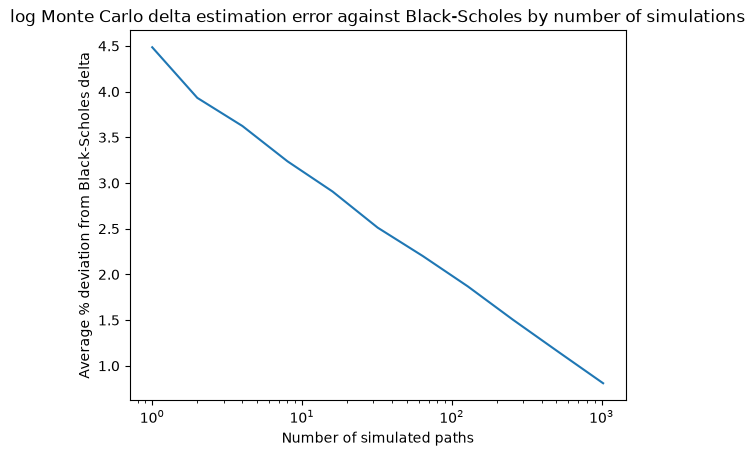

In [9]:
log_mean_errors = np.log(np.array(mean_errors))

plt.figure()
plt.plot(n_vals, log_mean_errors)
plt.title("log Monte Carlo delta estimation error against Black-Scholes by number of simulations")
plt.xlabel("Number of simulated paths")
plt.ylabel("Average % deviation from Black-Scholes delta")
plt.xscale('log')
plt.show()

Based on the same theory from 02_monte_carlo_option_valuation.ipynb, we can estimate the rate of convergence based on the gradient of the above line:

In [11]:
c1_est = (log_mean_errors[8] - log_mean_errors[1]) / (np.log(512) - np.log(4))

print(f"Gradient estimate: {round(c1_est, 4)}")

Gradient estimate: -0.5003


Again, we find $O(n^{-\frac{1}{2}})$ convergence.